<a href="https://colab.research.google.com/github/SathyaPrakashD/ml-pipeline-fundamentals/blob/main/14_heart_disease_data_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Round 14: Heart Disease — Data Engineering Overlay
## Applying Production Data Engineering Concepts

**Dataset:** UCI Heart Disease (Cleveland) — same dataset as Round 12  
**Purpose:** This notebook is not about modelling. It is about data engineering discipline.

**Concepts applied:**
- Pre-training validation block (schema, semantic, null, distribution)
- Systematic preprocessing via ColumnTransformer + Pipeline
- Leakage prevention — scaler fit on training data only
- Missingness indicator pattern (impute + flag)
- Evidence-based model comparison (Baseline → Model A → Model B)
- Explicit data lineage note

**Week 4 reference:** BITS Pilani AI Engineering — Module 2, Week 4

## Step 1: Data Loading and First Look
Goal: Load the dataset, understand its structure, identify column types,
and check for missing values before touching anything else.

In [3]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml

# Load Heart Disease dataset
data = fetch_openml(name='heart-disease', version=1, as_frame=True)
df = data.frame

# Basic overview
print("Shape:", df.shape)
print("\nColumn dtypes:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nClass distribution (target):")
print(df['target'].value_counts())

Shape: (303, 14)

Column dtypes:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target      float64
dtype: object

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Class distribution (target):
target
1.0    165
0.0    138
Name: count, dtype: int64


**Problem**

- There's a problem we need to address before moving forward.The missing values are gone.The original UCI Cleveland Heart Disease dataset has missing values in ca (4 missing) and thal (2 missing).

- OpenML has pre-cleaned them. This matters because one of our explicit Week 4 goals is practicing the missingness indicator pattern — and we can't do that on clean data.

- Fix — load the raw version directly from UCI:
- Replace your loading cell with this:

In [4]:
import pandas as pd
import numpy as np

# Load raw Cleveland Heart Disease data directly from UCI
# This preserves the original missing values marked as '?'
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

df = pd.read_csv(url, names=column_names, na_values='?')

# Binarise target (original has 0-4, we want 0 vs 1+)
df['target'] = (df['target'] > 0).astype(int)

print("Shape:", df.shape)
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nClass distribution:")
print(df['target'].value_counts())

Shape: (303, 14)

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Class distribution:
target
0    164
1    139
Name: count, dtype: int64


## Data Overview — Observations and Decisions

**Shape:** 303 rows, 14 columns (13 features + 1 target)

**Missing values:**
- `ca` (number of vessels coloured): 4 missing
- `thal` (thalassemia type): 2 missing
- All other columns: complete

**Missing value decision:**
- These are NOT empty data — a missing `ca` or `thal` in a clinical
  record may indicate the test was not performed or result was unavailable.
  This is a signal, not noise.
- Strategy: impute AND add a missingness indicator feature for both columns.
  We will not silently fill and move on.

**Class distribution:**
- **164 negative (no disease- 0 ), 139 positive (disease present - 1 )**
- Slight imbalance but not severe — no resampling required
- Lead metric will be F1 (weighted) — rationale: cost of false negative
  (missed disease) is higher than false positive, so recall matters

**Column type decisions:**
- Numerical: age, trestbps, chol, thalach, oldpeak (continuous, need scaling)
- Binary categorical (already 0/1): sex, fbs, exang (passthrough)
- Multi-class categorical: cp, restecg, slope, thal (need OneHotEncoding)
- Ordinal-ish: ca (0-3 vessels, treat as numerical)

## Step 2: Pre-Training Validation Block
Goal: Catch data problems BEFORE splitting or preprocessing.
This runs every time data enters the pipeline.

**Four checks**:

- Schema — all 14 columns present. No upstream changes have dropped or renamed anything.

- Semantic — no impossible values. Nobody has age -5 or heart rate 500. The data is clinically plausible.

- Null — ca (4 missing) and thal (2 missing) flagged and acknowledged. We will handle these intentionally in preprocessing, not ignore them.

- Distribution baseline — record these numbers. They become your reference point. If you run this notebook again after a data source change and chol mean jumps from 246 to 380, the validation report will show it

In [8]:
def validate_data(df):
    """
    Pre-training validation block.
    Runs before any splitting or preprocessing.
    Reports issues — does not crash the notebook.
    """
    print("=" * 50)
    print("DATA VALIDATION REPORT")
    print("=" * 50)

    # --- Schema Check ---
    print("\n[1] SCHEMA CHECK")
    expected_columns = [
        'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
        'restecg', 'thalach', 'exang', 'oldpeak', 'slope',
        'ca', 'thal', 'target'
    ]
    missing_cols = [c for c in expected_columns if c not in df.columns]
    if missing_cols:
        print(f"  FAIL — Missing columns: {missing_cols}")
    else:
        print("  PASS — All expected columns present")

    # --- Semantic Check ---
    print("\n[2] SEMANTIC CHECK")
    semantic_rules = {
        'age':      (0, 120),
        'trestbps': (0, 300),
        'chol':     (0, 600),
        'thalach':  (30, 220),
        'oldpeak':  (0, 10),
    }
    all_passed = True
    for col, (low, high) in semantic_rules.items():
        violations = df[(df[col] < low) | (df[col] > high)]
        if len(violations) > 0:
            print(f"  FAIL — {col}: {len(violations)} values outside [{low}, {high}]")
            all_passed = False
    if all_passed:
        print("  PASS — All numerical ranges within expected bounds")

    # --- Null Check ---
    print("\n[3] NULL CHECK")
    null_counts = df.isnull().sum()
    null_cols = null_counts[null_counts > 0]
    if len(null_cols) > 0:
        print("  INFO — Missing values detected (will be handled in preprocessing):")
        for col, count in null_cols.items():
            print(f"    {col}: {count} missing")
    else:
        print("  PASS — No missing values")

    # --- Distribution Baseline ---
    print("\n[4] DISTRIBUTION BASELINE")
    numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
    print(f"  {'Column':<12} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
    print(f"  {'-'*12} {'-'*8} {'-'*8} {'-'*8} {'-'*8}")
    for col in numerical_cols:
        print(f"  {col:<12} "
              f"{df[col].mean():>8.2f} "
              f"{df[col].std():>8.2f} "
              f"{df[col].min():>8.2f} "
              f"{df[col].max():>8.2f}")

    print("\n" + "=" * 50)
    print("VALIDATION COMPLETE")
    print("=" * 50)

# Run validation
validate_data(df)

DATA VALIDATION REPORT

[1] SCHEMA CHECK
  PASS — All expected columns present

[2] SEMANTIC CHECK
  PASS — All numerical ranges within expected bounds

[3] NULL CHECK
  INFO — Missing values detected (will be handled in preprocessing):
    ca: 4 missing
    thal: 2 missing

[4] DISTRIBUTION BASELINE
  Column           Mean      Std      Min      Max
  ------------ -------- -------- -------- --------
  age             54.44     9.04    29.00    77.00
  trestbps       131.69    17.60    94.00   200.00
  chol           246.69    51.78   126.00   564.00
  thalach        149.61    22.88    71.00   202.00
  oldpeak          1.04     1.16     0.00     6.20

VALIDATION COMPLETE


**Reading the report:**

- Schema — all 14 columns present. No upstream changes have dropped or renamed anything.
- Semantic — no impossible values. Nobody has age -5 or heart rate 500. The data is clinically plausible.
- Null — ca (4 missing) and thal (2 missing) flagged and acknowledged. We will handle these intentionally in preprocessing, not ignore them.
- Distribution baseline — record these numbers. They become your reference point. If you run this notebook again after a data source change and chol mean jumps from 246 to 380, the validation report will show it.

## Validation Report — Reading

- Schema: PASS — pipeline can proceed
- Semantic: PASS — no clinically impossible values detected
- Nulls: ca (4) and thal (2) — flagged, not dropped. Will apply impute + missingness indicator in Step 5.

- Distribution baseline recorded:
  - age mean: 54.44, chol mean: 246.69, thalach mean: 149.61
  - These are the reference stats for this dataset version.
  Any future run showing significant deviation warrants investigation.

## Step 3: Train/Test Split
Goal: Split BEFORE any preprocessing.

- This is non-negotiable.
- The scaler will be fit only on X_train.
- It will never see X_test during fitting.
- This directly prevents the global normalisation leakage pattern.

In [6]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Split BEFORE preprocessing — leakage prevention
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # preserves class balance in both splits
)

print("Train set size:", X_train.shape)
print("Test set size: ", X_test.shape)
print("\nClass distribution in train:")
print(y_train.value_counts())
print("\nClass distribution in test:")
print(y_test.value_counts())

# Leakage prevention — explicit comment for the record
print("\n[LEAKAGE PREVENTION]")
print("Scaler will be fit on X_train only.")
**Readin print("X_test will only be transformed, never used to fit.")

Train set size: (242, 13)
Test set size:  (61, 13)

Class distribution in train:
target
0    131
1    111
Name: count, dtype: int64

Class distribution in test:
target
0    33
1    28
Name: count, dtype: int64

[LEAKAGE PREVENTION]
Scaler will be fit on X_train only.
X_test will only be transformed, never used to fit.


**Reading Report**

- 242 train, 61 test — 80/20 split as planned.
- Stratification held — train is 131/111, test is 33/28.
- Both reflect the original ~54/46 class ratio. No accidental skew in either split.

## Step 4: Preprocessing Design Decisions
Goal: Decide HOW to preprocess each column BEFORE writing code.
Preprocessing is an architecture decision, not a cleaning task.

**Numerical columns — scaling choice:**
- age, trestbps, thalach, oldpeak → StandardScaler
  Reason: normally distributed, no severe outliers expected
- chol → StandardScaler
  Reason: one extreme value (564) but not severe enough for RobustScaler
- ca → treat as numerical, impute with median

**Missing value strategy:**
- ca (4 missing): impute with median + add ca_missing indicator column
- thal (2 missing): impute with most frequent + add thal_missing indicator column
- Reason: missing clinical values are signals, not noise. Blindly imputing
  erases the information that the measurement was unavailable.

**Categorical columns — encoding choice:**
- sex, fbs, exang → passthrough (already binary 0/1)
- cp, restecg, slope → OneHotEncoder (multi-class, no natural order)
- thal → OneHotEncoder after imputation (multi-class, no natural order)

**Leakage check on preprocessing decisions:**
- All scalers will be fit on X_train only
- Imputation statistics (median, most_frequent) computed on X_train only
- Applied forward to X_test

In [9]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## Step 5: ColumnTransformer + Pipeline
Goal: Implement the preprocessing decisions from Step 4 systematically.

Every transformation in code — nothing ad hoc, nothing buried in a cell.

This is Gap 1 closure — systematic preprocessing via Pipeline.

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
import numpy as np

# --- Define column groups ---
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
binary_cols    = ['sex', 'fbs', 'exang']
categorical_cols = ['cp', 'restecg', 'slope', 'thal']

# --- Numerical pipeline ---
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# --- Binary pipeline (passthrough — already 0/1) ---
# binary_pipeline = Pipeline([
#     ('passthrough', SimpleImputer(strategy='most_frequent'))
# ])

# Binary columns — passthrough only
# Missing values in these columns should be caught by validation block
# not silently imputed
binary_pipeline = Pipeline([
    ('passthrough', FunctionTransformer(lambda x: x))
])


# --- Categorical pipeline ---
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# --- ColumnTransformer ---
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline,  numerical_cols),
    ('bin', binary_pipeline,     binary_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

# --- Fit on X_train ONLY — transform both ---
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape: ", X_test_processed.shape)
print("\nPreprocessor fit on X_train only.")
print("X_test transformed using X_train statistics — no leakage.")

X_train_processed shape: (242, 22)
X_test_processed shape:  (61, 22)

Preprocessor fit on X_train only.
X_test transformed using X_train statistics — no leakage.


**Reading Report**

- You started with 13 features. You ended with 22. Account for every column?

- numerical_cols — age, trestbps, chol, thalach, oldpeak, ca → how many?
- binary_cols — sex, fbs, exang → how many?
- categorical_cols — cp, restecg, slope, thal → these get OneHotEncoded.

**How many unique values does each have?**


**Check the unique values with this quick cell:**

In [11]:
for col in ['cp', 'restecg', 'slope', 'thal']:
    print(f"{col}: {sorted(df[col].dropna().unique())}")

cp: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
restecg: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]
slope: [np.float64(1.0), np.float64(2.0), np.float64(3.0)]
thal: [np.float64(3.0), np.float64(6.0), np.float64(7.0)]


- Numerical columns — age, trestbps, chol, thalach, oldpeak, ca → 6 columns
- Binary columns — sex, fbs, exang → 3 columns
- Categorical columns after OneHotEncoding:

  - cp has 4 unique values → 4 columns
  - restecg has 3 unique values → 3 columns
  - slope has 3 unique values → 3 columns
  - thal has 3 unique values → 3 columns

Total: 6 + 3 + 4 + 3 + 3 + 3 = 22

## Step 5b: Missingness Indicator

Goal: Add binary flag columns for ca and thal before preprocessing.

Missing clinical values are signals — we preserve that signal by adding an indicator column alongside the imputed value.

In [15]:
# Add missingness indicator columns BEFORE preprocessing
# Do this on both train and test using X_train's missing pattern

def add_missing_indicators(X):
    X = X.copy()
    X['ca_missing']   = X['ca'].isnull().astype(int)
    X['thal_missing'] = X['thal'].isnull().astype(int)
    return X

X_train = add_missing_indicators(X_train)
X_test  = add_missing_indicators(X_test)

print("X_train shape after indicators:", X_train.shape)
print("X_test shape after indicators: ", X_test.shape)
print("\nMissingness indicators in X_train:")
print(X_train[['ca', 'ca_missing', 'thal', 'thal_missing']].head(10))
print("\n")
print(X_train.head(1))

X_train shape after indicators: (242, 15)
X_test shape after indicators:  (61, 15)

Missingness indicators in X_train:
      ca  ca_missing  thal  thal_missing
180  0.0           0   7.0             0
208  0.0           0   3.0             0
167  1.0           0   3.0             0
105  0.0           0   7.0             0
297  0.0           0   7.0             0
120  2.0           0   7.0             0
55   1.0           0   7.0             0
123  0.0           0   7.0             0
70   0.0           0   3.0             0
272  2.0           0   7.0             0


      age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
180  48.0  1.0  4.0     124.0  274.0  0.0      2.0    166.0    0.0      0.5   

     slope   ca  thal  ca_missing  thal_missing  
180    2.0  0.0   7.0           0             0  


## Step 5c: Rerun Preprocessor with Missingness Indicators
The two indicator columns ca_missing and thal_missing are binary (0 or 1).
They go into binary_cols — no scaling needed, no imputation needed.

In [16]:
# Updated column groups — now including missingness indicators
numerical_cols   = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
binary_cols      = ['sex', 'fbs', 'exang', 'ca_missing', 'thal_missing']
categorical_cols = ['cp', 'restecg', 'slope', 'thal']

# Rebuild preprocessor with updated column groups
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline,  numerical_cols),
    ('bin', binary_pipeline,     binary_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

# Fit on X_train ONLY — transform both
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape: ", X_test_processed.shape)
print("\nColumn count breakdown:")
print(f"  Numerical:   {len(numerical_cols)} columns")
print(f"  Binary:      {len(binary_cols)} columns")
print(f"  Categorical: cp(4) + restecg(3) + slope(3) + thal(3) = 13 columns")
print(f"  Total expected: {len(numerical_cols) + len(binary_cols) + 13}")

X_train_processed shape: (242, 24)
X_test_processed shape:  (61, 24)

Column count breakdown:
  Numerical:   6 columns
  Binary:      5 columns
  Categorical: cp(4) + restecg(3) + slope(3) + thal(3) = 13 columns
  Total expected: 24


**Reading Report**

Perfect. 24 columns — exactly as expected and fully accounted for.

The full column breakdown:

- 6 numerical (including ca)
- 5 binary (including ca_missing and thal_missing — the missingness indicators)
- 13 from OneHotEncoding (4 + 3 + 3 + 3)

## Step 6: Baseline Model — DummyClassifier
Goal: Establish the performance floor.

Any real model that cannot beat this has learned nothing.

The DummyClassifier ignores all features and predicts the most frequent class.

In [18]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Baseline — most frequent class predictor
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_processed, y_train)
dummy_preds = dummy.predict(X_test_processed)

print("BASELINE — DummyClassifier (most_frequent)")
print("-" * 40)
print(f"Accuracy: {accuracy_score(y_test, dummy_preds):.4f}")
print(f"F1 Score: {f1_score(y_test, dummy_preds, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, dummy_preds))

BASELINE — DummyClassifier (most_frequent)
----------------------------------------
Accuracy: 0.5410
F1 Score: 0.3798

Classification Report:
              precision    recall  f1-score   support

           0       0.54      1.00      0.70        33
           1       0.00      0.00      0.00        28

    accuracy                           0.54        61
   macro avg       0.27      0.50      0.35        61
weighted avg       0.29      0.54      0.38        61



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Reading Report**

## Baseline Results — Floor Established

DummyClassifier predicts class 0 (no disease) for every patient.
Never predicts class 1 — precision for class 1 is undefined.

Floor:
- Accuracy: 0.5410
- F1 (weighted): 0.3798

Any real model must beat F1 = 0.38 to prove it has learned something.

Lead metric: F1 (weighted)

Reason: Cost of false negative (missed disease) > cost of false positive.
        F1 balances precision and recall — appropriate for this domain.

## Step 7: Model A — Logistic Regression
Logistic Regression is the natural first real model for binary classification.

It is interpretable, fast, and gives a strong baseline for linear relationships.

If Random Forest does not significantly outperform it,

Logistic Regression is preferable for its interpretability.

MODEL A — Logistic Regression
----------------------------------------
Accuracy: 0.8689
F1 Score: 0.8690

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



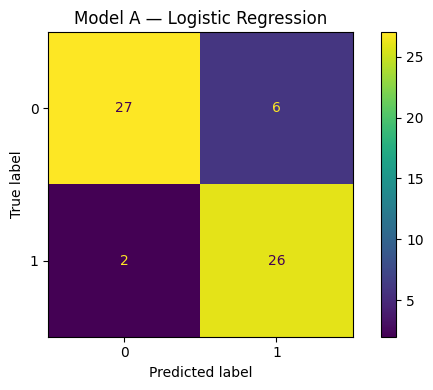

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Model A — Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_processed, y_train)
lr_preds = lr.predict(X_test_processed)

print("MODEL A — Logistic Regression")
print("-" * 40)
print(f"Accuracy: {accuracy_score(y_test, lr_preds):.4f}")
print(f"F1 Score: {f1_score(y_test, lr_preds, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_preds))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test, lr_preds, ax=ax)
ax.set_title("Model A — Logistic Regression")
plt.tight_layout()
plt.show()

**Reading Report**

Strong result. Let's read it properly before moving to Model B.

Against the floor:

Baseline F1: 0.38 → Model A F1: 0.87.

That is more than double the floor.

Logistic Regression has clearly learned something meaningful.

Reading the classification report:

Class 0 (no disease): Precision 0.93, Recall 0.82 — when it predicts no disease, it is right 93% of the time.

Class 1 (disease): Precision 0.81, Recall 0.93 — it catches 93% of actual disease cases.


The recall for class 1 is 0.93.

In a medical context this is the number that matters most. Missing a disease case (false negative) is more dangerous than a false alarm (false positive).

Logistic Regression is catching 93% of actual disease patients. That is a strong result.


## Model A Results — Logistic Regression

- Accuracy: 0.8689
- F1 (weighted): 0.8690

**Key observation**:
Recall for class 1 (disease) = 0.93
This means 93% of actual disease cases are correctly identified.

In a clinical context this is the critical number —
missing a disease case is more dangerous than a false alarm.

Beats baseline F1 of 0.38 by a significant margin.

Bar for Model B to beat: F1 > 0.87

## Step 8: Model B — Random Forest
Random Forest is an ensemble method — it builds multiple decision trees
and aggregates their predictions. It handles non-linear relationships
and feature interactions that Logistic Regression may miss.
Question: Does the added complexity actually improve performance?
Evidence will decide — not assumption.

MODEL B — Random Forest
----------------------------------------
Accuracy: 0.8689
F1 Score: 0.8690

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



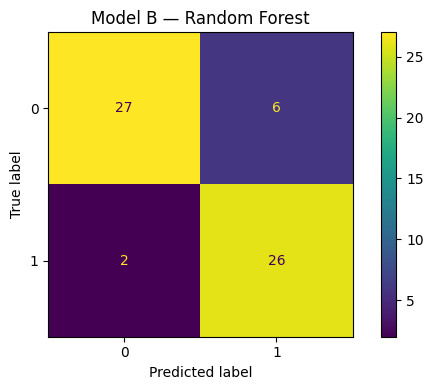

In [20]:
from sklearn.ensemble import RandomForestClassifier

# Model B — Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_processed, y_train)
rf_preds = rf.predict(X_test_processed)

print("MODEL B — Random Forest")
print("-" * 40)
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(f"F1 Score: {f1_score(y_test, rf_preds, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test, rf_preds, ax=ax)
ax.set_title("Model B — Random Forest")
plt.tight_layout()
**Readin plt.show()

**Reading Report**

Interesting result. Both models produced identical scores.
Two models with identical F1 scores. One is simpler, one is more complex.

Which one do you pick as the winner and why?

Pick Logistic Regression — identical F1 score means no benefit from the added complexity of Random Forest.

The data is likely linear — if non-linear relationships existed that Random Forest could exploit, it would have scored higher.

The fact that it did not suggests Logistic Regression is capturing the signal adequately Simpler model is always preferred when performance is equal — easier to interpret, explain, debug, and deploy

## Step 9: Model Comparison and Winner Selection

| Model               | Accuracy | F1 (weighted) |
|---------------------|----------|---------------|
| Baseline (Dummy)    | 0.5410   | 0.3798        |
| Model A (Logistic)  | 0.8689   | 0.8690        |
| Model B (Rnd Forest)| 0.8689   | 0.8690        |

**Winner: Logistic Regression**

Reason: Identical performance to Random Forest.
When performance is equal, the simpler model is always preferred.
Simpler models are more interpretable, easier to debug, and safer to deploy.
Equal F1 scores suggest the data has linear separability —
Logistic Regression is sufficient to capture the signal.

Recall for class 1 (disease detected): 0.93
This is the clinically critical metric — 93% of disease cases caught.

## Step 10: Data Lineage Note
Reproducibility is accountability.

If this notebook fails in production tomorrow,

this section answers: what exactly did we train on?

In [21]:
from datetime import datetime

print("=" * 55)
print("DATA LINEAGE NOTE")
print("=" * 55)
print(f"Date built:        {datetime.today().strftime('%Y-%m-%d')}")
print(f"Dataset:           UCI Heart Disease (Cleveland)")
print(f"Source:            UCI ML Repository — processed.cleveland.data")
print(f"Rows:              {df.shape[0]}")
print(f"Features:          {df.shape[1] - 1}")
print(f"Target:            Binary (0 = no disease, 1 = disease present)")
print(f"Train/test split:  80/20, stratified, random_state=42")
print(f"Missing values:    ca (4), thal (2) — imputed + indicator added")
print(f"Scaling:           StandardScaler fit on X_train only")
print(f"Encoding:          OneHotEncoder for cp, restecg, slope, thal")
print(f"Binary cols:       Passthrough — no scaling, no imputation")
print(f"Lead metric:       F1 (weighted)")
print(f"Baseline F1:       0.3798")
print(f"Winner:            Logistic Regression — F1: 0.8690")
print(f"Winner reason:     Equal performance to Random Forest.")
print(f"                   Simpler model preferred.")
print(f"Recall class 1:    0.93 — 93% of disease cases caught")
print(f"Leakage check:     Scaler fit on X_train only.")
print(f"                   No test data seen during fitting.")
print("=" * 55)

DATA LINEAGE NOTE
Date built:        2026-04-04
Dataset:           UCI Heart Disease (Cleveland)
Source:            UCI ML Repository — processed.cleveland.data
Rows:              303
Features:          13
Target:            Binary (0 = no disease, 1 = disease present)
Train/test split:  80/20, stratified, random_state=42
Missing values:    ca (4), thal (2) — imputed + indicator added
Scaling:           StandardScaler fit on X_train only
Encoding:          OneHotEncoder for cp, restecg, slope, thal
Binary cols:       Passthrough — no scaling, no imputation
Lead metric:       F1 (weighted)
Baseline F1:       0.3798
Winner:            Logistic Regression — F1: 0.8690
Winner reason:     Equal performance to Random Forest.
                   Simpler model preferred.
Recall class 1:    0.93 — 93% of disease cases caught
Leakage check:     Scaler fit on X_train only.
                   No test data seen during fitting.
